In [1]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd
import frequency_func as ff
from scipy.optimize import curve_fit

In [2]:
outfile_name="km"
Tcm=32
dm2=1e-18
ke=0.9
km=1.8
B=np.array([0.8,0,-0.6])
A_const=1

def e0(ke,km):
    dk=ke-km
    eps=np.log(ke/km)
    eps=eps*3/dk
    return eps

eps_i=100
# theta0=pi-2theta_mixing -> cos theta0=-cos theta_mix, sin theta0=sin theta0

In [3]:
l_small=5
km_small=np.linspace(0.25,0.5,l_small+1)*km # modified to better suit integral
km_small=km_small[:-1]

kf_small=np.empty((len(km_small)),dtype=float)
small=np.empty((l_small))
V_small=np.empty((l_small,1001))
B_small=np.empty((l_small,1001,206))
# Ss=np.empty((l_small,3,1001,206))
wn_small=np.empty((l_small))
con_small=np.empty((l_small))
wn_con_small=np.empty((l_small))

for i in range(l_small):
#     print(km_small[i])
    pd.run_coherentsolve(outfile_name, Tcm, dm2, ke, km_small[i], ke, km_small[i])
    data=ff.return_data(outfile_name)
    f=ff.frequency(data,dm2)
    time=data['time']
    co=f[0]
#     print('co',co)
    cycle=f[1]
    min=f[2]
    af=f[3]
    A_const=0.9/np.max((ke**3,km_small[i]**3)) # A_const=1.2345679 for km_small values
    print(A_const)
    wn_small[i]=0.5*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*A_const/(np.pi**2)*(ke-km_small[i])
    
    P0, Px, Py, Pz = pd.make_P(data['rho']) # [t(1001),e(206)]
    P0bar, Pxbar, Pybar, Pzbar = pd.make_P(data['rhobar'])
    eps = data['eps']
    w=data['w']
    S=np.array([(P0*Px)+(P0bar*Pxbar),(P0*Py)+(P0bar*Pybar),(P0*Pz)+(P0bar*Pzbar)])
    A=np.array([(P0*Px)-(P0bar*Pxbar),(P0*Py)-(P0bar*Pybar),(P0*Pz)-(P0bar*Pzbar)])
    S0=np.array(np.sqrt(S[0,0]**2+S[1,0]**2+S[2,0]**2)) # magnitude constant relative to time, so find S0 for t=0 only,
            
        
    B_angle=np.empty((len(time),len(eps)),dtype=float)
    s0=0
    integrand=np.empty((len(eps)))
    for e in range(len(eps)):
        for t in range(len(time)):
            B_angle[t,e]=np.dot(B,S[:,t,e])/S0[e]
        
        integrand[e]=w[e]*eps[e]*S0[e]*np.sign(B_angle[0,e])*-1
        s0+=integrand[e]
#     small[i]=s0*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2)
    con_small[i]=np.sqrt(s0*(1-0.6)*2*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2)) # this is technically negative, but i flipped cos max and cos init
    wn_con_small[i]=np.sqrt(2*(1-0.6)*wn_small[i])
    
    Vs=pd.V_mat(data)
    
    kf_small[i]=af
    V_small[i]=Vs[1]
    B_small[i]=B_angle

#     plt.figure()
#     plt.title('Km='+str(km_small[i]))
# #     plt.plot(Px[:,eps_i],Pz[:,eps_i])
#     plt.scatter(eps,integrand)


1.2345679012345678
1.2345679012345678
1.2345679012345678
1.2345679012345678
1.2345679012345678


In [4]:
l_big=5
km_big=np.linspace(0.5,1.5,l_big+1)*km
km_big=km_big[1:]

kf_big=np.empty((len(km_big)),dtype=float)
big=np.empty((l_big))
V_big=np.empty((l_big,1001))
B_big=np.empty((l_big,1001,206))
wn_big=np.empty((l_big))
con_big=np.empty((l_big))
wn_con_big=np.empty((l_big))

for i in range(len(km_big)):
    pd.run_coherentsolve(outfile_name, Tcm, dm2, ke, km_big[i], ke, km_big[i])
    data=ff.return_data(outfile_name)
    f=ff.frequency(data,dm2)
    time=data['time']
    co=f[0]
    cycle=f[1]
    min=f[2]
    af=f[3]
    A_const=0.9/np.max((ke**3,km_big[i]**3))
    print(A_const)
    wn_big[i]=0.5*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*A_const*(km_big[i]-ke)/(np.pi**2) # (km_big-ke)=-1*(ke-km_small)
    
    P0, Px, Py, Pz = pd.make_P(data['rho'])
    P0bar, Pxbar, Pybar, Pzbar = pd.make_P(data['rhobar'])
    eps = data['eps']
    w=data['w']
    S=np.array([(P0*Px)+(P0bar*Pxbar),(P0*Py)+(P0bar*Pybar),(P0*Pz)+(P0bar*Pzbar)])
    A=np.array([(P0*Px)-(P0bar*Pxbar),(P0*Py)-(P0bar*Pybar),(P0*Pz)-(P0bar*Pzbar)])
    S0=np.array(np.sqrt(S[0,0]**2+S[1,0]**2+S[2,0]**2))
    
    B_angle=np.empty((len(time),len(eps)),dtype=float)
    integrand=np.empty((len(eps)))
    s0=0
    for e in range(len(eps)):
        for t in range(len(time)):
            B_angle[t,e]=np.dot(B,S[:,t,e])/S0[e]
        
        integrand[e]=w[e]*eps[e]*S0[e]*np.sign(B_angle[0,e])*-1*-1
        s0+=integrand[e]
    big[i]=s0*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2)
    con_big[i]=np.sqrt(s0*(1+0.6)*2*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2))
    wn_con_big[i]=np.sqrt(2*(1+0.6)*wn_big[i])
       
    Vs=pd.V_mat(data)
    
    kf_big[i]=af
    V_big[i]=Vs[1]
    B_big[i]=B_angle
    
#     plt.figure()
#     plt.title('Km='+str(km_big[i]))
#     plt.scatter(eps,integrand)

0.44991541590181044
0.21168859760537856
0.11594364211444098
0.07024168759868954
0.045724737082761764


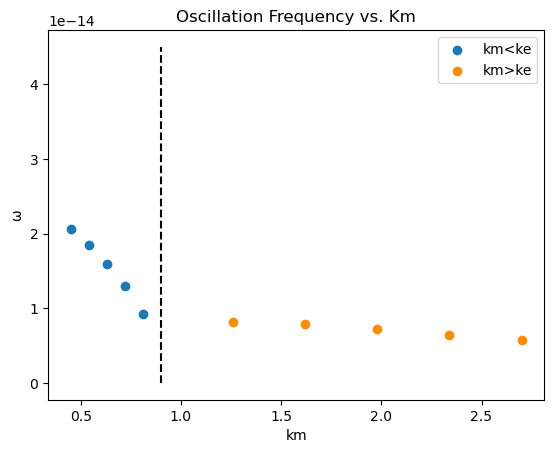

In [5]:
plt.scatter(km_small,kf_small, label='km<ke')
plt.scatter(km_big,kf_big,color='darkorange',label='km>ke')
# plt.xlim(0,13)
# plt.ylim(0.5e-14,4.5e-14)
plt.plot([ke]*10,np.linspace(0,4.5e-14,10),'--',color='black')
# plt.scatter(km_big[1],kf_big[0,1],label='max',color='red',marker='s')
plt.title('Oscillation Frequency vs. Km')
# plt.plot(np.linspace(0.25*km,2*km,10),[0]*10,'--',color='red')
plt.ylabel('ω')
plt.xlabel('km')
plt.legend()

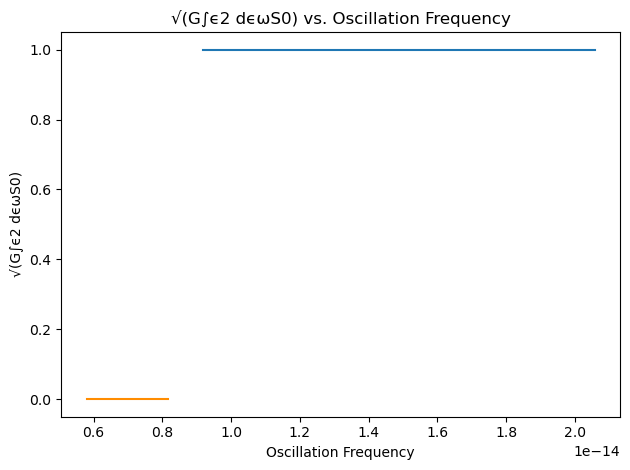

In [6]:
plt.title('√(G∫ϵ2 dϵωS0) vs. Oscillation Frequency')
plt.xlabel('Oscillation Frequency')
plt.ylabel('√(G∫ϵ2 dϵωS0)')
plt.plot(kf_small,small**0.5)
plt.plot(kf_big,big**.5,color='darkorange')
plt.tight_layout()

In [7]:
for kv in range(l_small):
    # plt.plot(np.linspace(0,1,3),[np.max(V_small[kv])]*3)
    # plt.plot(np.linspace(0,1,3),[np.sqrt(3.2*small[kv])]*3)
    print('km=',km_small[kv])
    print('Max V value: ', np.max(V_small[kv]))
#     print('Integrand=',small[kv])
    print('Con=',con_small[kv])
#     print('<w>n:', wn_small[kv])
    print('Con wn=',wn_con_small[kv])
#     print('Ratio sqrt(Integrand): ', np.max(V_small[kv])/np.sqrt(small[kv]))
    print('Ratio (Con): ', np.max(V_small[kv])/con_small[kv])
#     print('Ratio sqrt(<w>n): ',np.max(V_small[kv])/np.sqrt(wn_small[kv]))
    print('Ratio (Con wn): ', np.max(V_small[kv])/wn_con_small[kv])
#     print('Debugging Ratio (con/con wn): ',con_small[kv]/wn_con_small[kv])
#     print('Angular Frequency: ',kf_small[kv])
#     print('Ratio (af*2pi): ',np.max(V_small[kv])/kf_small[kv]*2*np.pi)
    print()
for kv in range(l_big):
    print('km=',km_big[kv])
    print('Max V value: ', np.max(V_big[kv]))
#     print('Integrand=',big[kv])
    print('Con=',con_big[kv])
#     print('<w>n:', wn_big[kv])
    print('Con wn=',wn_con_big[kv])
#     print('Ratio sqrt(Integrand): ', np.max(V_big[kv])/np.sqrt(big[kv]))
    print('Ratio (Con): ', np.max(V_big[kv])/con_big[kv])
#     print('Ratio sqrt(<w>n): ',np.max(V_big[kv])/np.sqrt(wn_big[kv]))
    print('Ratio (Con wn): ', np.max(V_big[kv])/wn_con_big[kv])
#     print('Debugging Ratio (con/con wn): ',con_big[kv]/wn_con_big[kv])
#     print('Angular Frequency: ',kf_big[kv])
#     print('Ratio (af/2pi): ',np.max(V_big[kv])/kf_big[kv]*2*np.pi)
    print()

km= 0.45
Max V value:  9.768638536390737e-15
Con= 1.94869650952367e-14
Con wn= 1.949847396229184e-14
Ratio (Con):  0.50129091362608
Ratio (Con wn):  0.500995029420371

km= 0.54
Max V value:  8.73672029063403e-15
Con= 1.742843118464265e-14
Con wn= 1.743996529487769e-14
Ratio (Con):  0.501291263572394
Ratio (Con wn):  0.500959729157265

km= 0.63
Max V value:  7.565636102207497e-15
Con= 1.5092291470834843e-14
Con wn= 1.5103452986483048e-14
Ratio (Con):  0.501291412031615
Ratio (Con wn):  0.5009209555575418

km= 0.7200000000000001
Max V value:  6.176792546610985e-15
Con= 1.232176394752577e-14
Con wn= 1.2331917723666059e-14
Ratio (Con):  0.5012912577221782
Ratio (Con wn):  0.500878507708267

km= 0.81
Max V value:  4.367239187393912e-15
Con= 8.712008388535899e-15
Con wn= 8.719982647438843e-15
Ratio (Con):  0.5012895985202156
Ratio (Con wn):  0.5008311786809139

km= 1.26
Max V value:  1.0539528975392878e-14
Con= 2.1025396922389632e-14
Con wn= 2.105637267326221e-14
Ratio (Con):  0.501276100246